# 02 Plot

Loads `../output/full_dataset.csv` and generates publication figures.

**Output:** `../output/figures/`

| Figure | Description |
|---|---|
| `fig1_pllps_distribution` | pLLPS score histogram coloured by class |
| `fig2_membrane_vs_nonmembrane` | violin + box: membrane vs non-membrane |
| `fig3_group_size_histograms` | histograms: membrane group sizes for function and location |
| `fig3_by_function` | violin with quartile markers: pLLPS by primary functional group (membrane) |
| `fig3_by_function_observations` | points + quartile box: pLLPS by primary functional group (membrane) |
| `fig4_by_location` | box: pLLPS by subcellular location, all proteins |
| `fig5_kde_distributions` | KDE: all / membrane+non-membrane / by TMD count |
| `fig6_membrane_by_function` | violin + box: membrane subset by function (top groups by count) |
| `fig7_membrane_by_location` | violin + box: membrane subset by location (top groups by count) |
| `fig8_pct_above_cutoff_function` | % pLLPS > 0.6 by function, membrane subset, n= labels |
| `fig9_pct_above_cutoff_location` | % pLLPS > 0.6 by location, membrane subset, n= labels |

In [1]:
from ast import literal_eval
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 11, "axes.labelsize": 12, "xtick.labelsize": 9, "ytick.labelsize": 9})

DATA    = Path("../output/full_dataset.csv")
FIG_DIR = Path("../output/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

CUTOFF = 0.6  # threshold for enrichment barplots

# Okabe-Ito colorblind-friendly palette
C = {
    "Membrane":     "#0072B2",
    "Non-Membrane": "#E69F00",
    "Cytosolic":    "#009E73",
    "High":         "#e74c3c",
    "Medium":       "#f39c12",
    "Low":          "#3498db",
}


In [2]:
df = pd.read_csv(DATA)
REQUIRED_COLUMNS = [
    "Function_Top",
    "Location_Top",
    "p(LLPS)",
    "pLLPS_Class",
    "TMD_count",
]
missing = [col for col in REQUIRED_COLUMNS if col not in df.columns]
if missing:
    raise KeyError(f"Missing required columns in {DATA}: {missing}")

# Keep only the GO-derived columns that the plots actually use.
df["TMD_count"] = pd.to_numeric(df["TMD_count"], errors="coerce").fillna(0).astype(int)
df["Is_Membrane"] = df["TMD_count"] > 0

def _as_list(value):
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        text = value.strip()
        if text.startswith("[") and text.endswith("]"):
            try:
                parsed = literal_eval(text)
            except (ValueError, SyntaxError):
                return []
            return parsed if isinstance(parsed, list) else []
    return []

df["Location_Slim"] = df["Location_Slim"].apply(_as_list)
df["Location_Slim_Plot"] = df["Location_Slim"].apply(lambda values: values if values else ["Unannotated"])

print(f"{len(df):,} proteins  |  {df['pLLPS_Class'].value_counts().to_dict()}")
print(f"Membrane (TMD>0): {df['Is_Membrane'].sum():,}  |  TMD_count unique: {sorted(df['TMD_count'].unique())[:10]}")
print(f"Primary locations (GO): {df['Location_Top'].nunique():,}  |  Primary functions (GO): {df['Function_Top'].nunique():,}")
df.head(2)

20,366 proteins  |  {'Low': 10797, 'High': 6568, 'Medium': 3001}
Membrane (TMD>0): 5,218  |  TMD_count unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Primary locations (GO): 25  |  Primary functions (GO): 103


,Entry,Entry name,Protein names,p(LLPS),n(DPR=> 25),Organism,Length,Function [CC],Involvement in disease,Cross-reference (PDB),...,GO_MF,GO_CC,Function_Slim,Location_Slim,Function_Top,Location_Top,TMD_count,Is_Membrane,Compartment,Location_Slim_Plot
0,Q9Y6V0,PCLO_HUMAN,Protein piccolo (Aczonin),1.0,21,Homo sapiens (Human),5142.0,Scaffold protein of the presynaptic cytomatri...,Pontocerebellar hypoplasia 3 (PCH3) [MIM:6080...,1UJD;,...,"['GO:0005509', 'GO:0005522', 'GO:0005544', 'GO...","['GO:0005856', 'GO:0014069', 'GO:0030424', 'GO...","['cytoskeleton organization', 'vesicle-mediate...","[cytoskeleton, organelle]",cytoskeleton organization,cytoskeleton,0,False,cytoskeleton,"[cytoskeleton, organelle]"
1,Q9Y566,SHAN1_HUMAN,SH3 and multiple ankyrin repeat domains protei...,1.0,8,Homo sapiens (Human),2161.0,Seems to be an adapter protein in the postsyn...,NaN,6CPI;,...,"['GO:0017124', 'GO:0030160', 'GO:0031877', 'GO...","['GO:0005829', 'GO:0005886', 'GO:0014069', 'GO...","['cell junction organization', 'nervous system...","[cytosol, plasma membrane, organelle]",cell junction organization,cytosol,0,False,cytosol,"[cytosol, plasma membrane, organelle]"


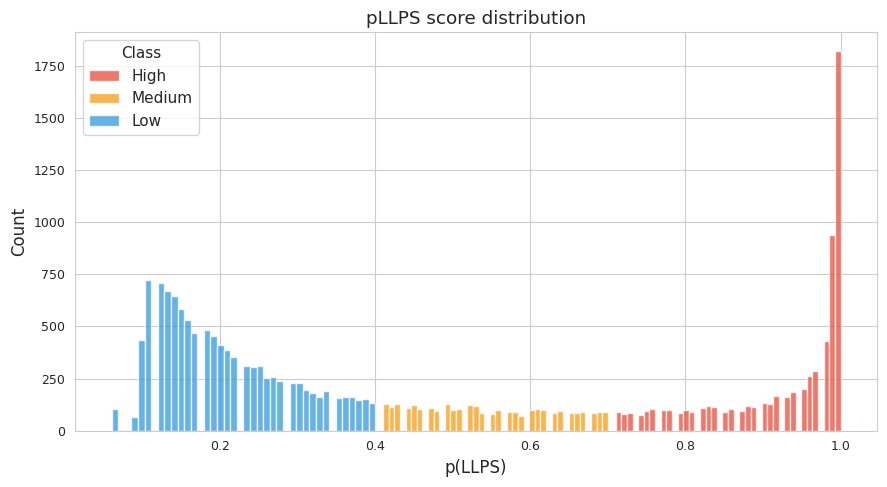

In [3]:
# Fig 1 — pLLPS score distribution
fig, ax = plt.subplots(figsize=(9, 5))
for cls in ["High", "Medium", "Low"]:
    ax.hist(df[df["pLLPS_Class"] == cls]["p(LLPS)"], bins=40, alpha=0.75,
            color=C[cls], label=cls)
ax.set(xlabel="p(LLPS)", ylabel="Count", title="pLLPS score distribution")
ax.legend(title="Class")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_pllps_distribution.png", dpi=300)
plt.show()

/tmp/ipykernel_11039/4025223080.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long, x="Group", y="pLLPS", inner="quartile", cut=0,


/tmp/ipykernel_11039/4025223080.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long, x="Group", y="pLLPS", width=0.4, showfliers=False,


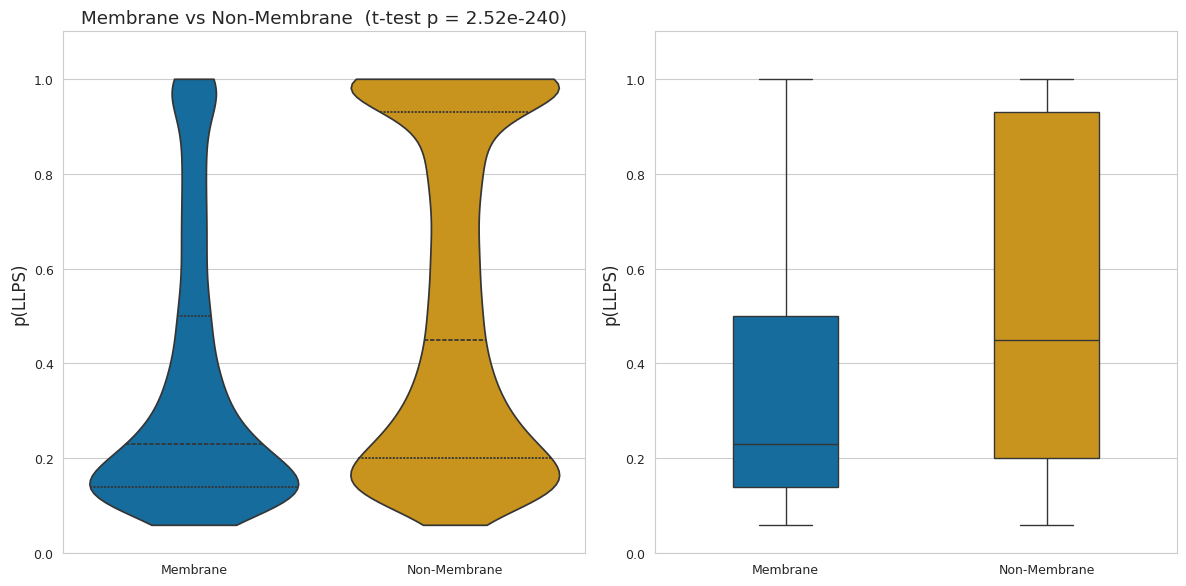

In [4]:
# Fig 2 — membrane vs non-membrane
groups = {
    "Membrane":     df[df["Is_Membrane"] == True]["p(LLPS)"].dropna(),
    "Non-Membrane": df[df["Is_Membrane"] == False]["p(LLPS)"].dropna(),
}
long = pd.concat(
    [s.rename("pLLPS").to_frame().assign(Group=k) for k, s in groups.items()]
)
_, p = stats.ttest_ind(*groups.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
palette = [C[g] for g in groups]
sns.violinplot(data=long, x="Group", y="pLLPS", inner="quartile", cut=0,
               palette=palette, ax=axes[0])
sns.boxplot(data=long, x="Group", y="pLLPS", width=0.4, showfliers=False,
            palette=palette, ax=axes[1])
for ax in axes:
    ax.set(ylim=(0, 1.1), xlabel="", ylabel="p(LLPS)")
axes[0].set_title(f"Membrane vs Non-Membrane  (t-test p = {p:.2e})")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_membrane_vs_nonmembrane.png", dpi=300)
plt.show()

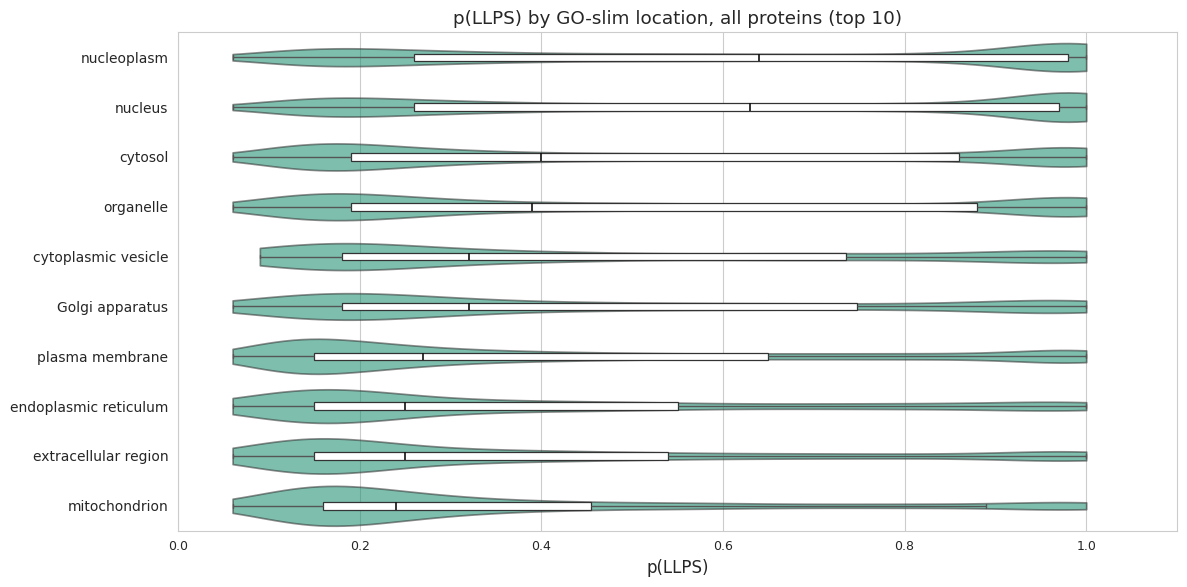

In [5]:
# Fig 4 — pLLPS by GO-slim location (all proteins, top 10 by count)
loc_long = (
    df[["p(LLPS)", "Location_Slim_Plot"]]
    .explode("Location_Slim_Plot")
    .dropna(subset=["Location_Slim_Plot"])
    .query("Location_Slim_Plot != 'Other' and Location_Slim_Plot != ''")
    .rename(columns={"Location_Slim_Plot": "Location"})
)
loc_long = loc_long[loc_long["Location"] != "Unannotated"]
top_locs = loc_long["Location"].value_counts().nlargest(10).index
loc_long = loc_long[loc_long["Location"].isin(top_locs)]
order_locs = (
    loc_long.groupby("Location")["p(LLPS)"]
    .median()
    .sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(12, max(6, 0.42 * len(order_locs) + 1.5)))
sns.violinplot(data=loc_long, y="Location", x="p(LLPS)", order=order_locs,
               inner=None, cut=0, color=C["Cytosolic"], alpha=0.55, ax=ax)
sns.boxplot(data=loc_long, y="Location", x="p(LLPS)", order=order_locs,
            width=0.15, showfliers=False, ax=ax,
            boxprops={"facecolor": "white", "edgecolor": "#333333", "linewidth": 0.9},
            whiskerprops={"color": "#555555"}, capprops={"color": "#555555"},
            medianprops={"color": "#111111", "linewidth": 1.2})
ax.set(xlim=(0, 1.1), xlabel="p(LLPS)", ylabel="",
       title="p(LLPS) by GO-slim location, all proteins (top 10)")
ax.tick_params(axis="y", labelsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_by_location.png", dpi=300, bbox_inches="tight")
plt.show()


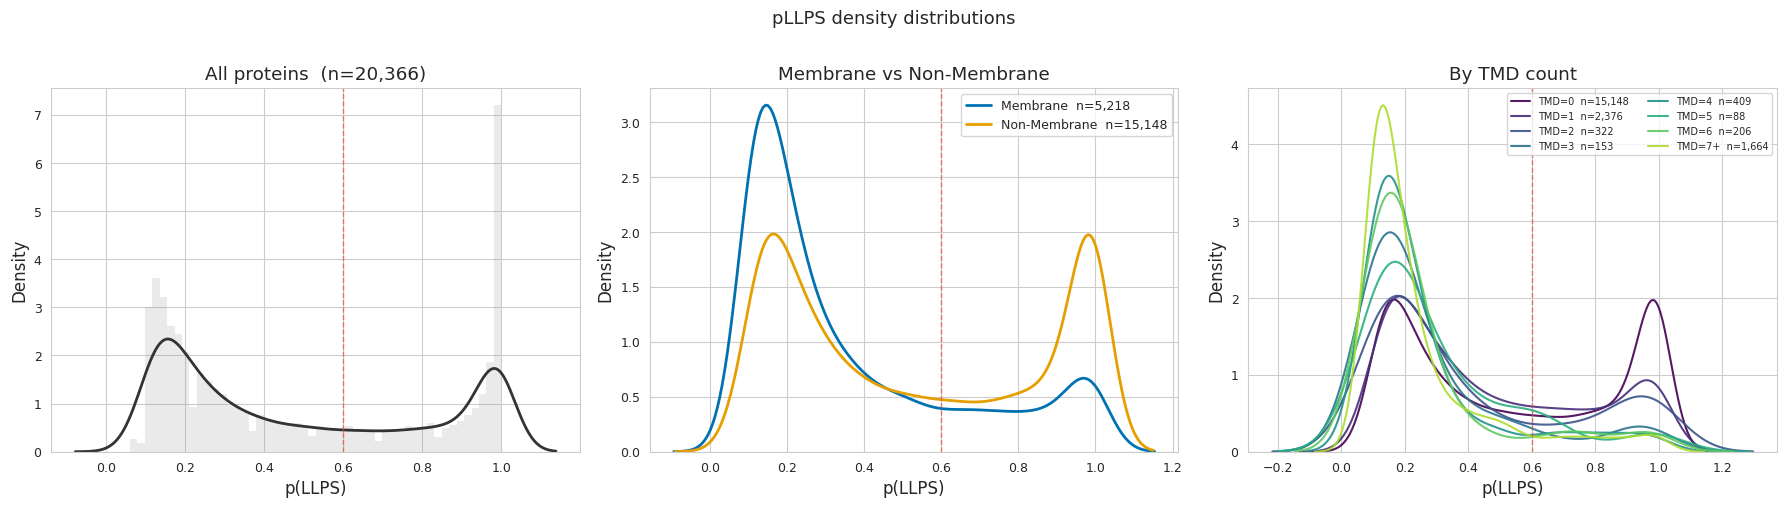

In [6]:
# Fig 5 — KDE: all proteins / membrane vs non-membrane / by TMD count
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A: all proteins
s_all = df["p(LLPS)"].dropna()
axes[0].hist(s_all, bins=50, density=True, alpha=0.2, color="#999999", edgecolor="none")
sns.kdeplot(s_all, ax=axes[0], color="#333333", linewidth=2)
axes[0].set(xlabel="p(LLPS)", ylabel="Density", title=f"All proteins  (n={len(s_all):,})")
axes[0].axvline(CUTOFF, color="#e74c3c", linestyle="--", linewidth=1, alpha=0.7)

# B: membrane vs non-membrane
for label, color in [("Membrane", C["Membrane"]), ("Non-Membrane", C["Non-Membrane"])]:
    s = df[df["Is_Membrane"] == (label == "Membrane")]["p(LLPS)"].dropna()
    sns.kdeplot(s, ax=axes[1], color=color, linewidth=2, label=f"{label}  n={len(s):,}")
axes[1].set(xlabel="p(LLPS)", ylabel="Density", title="Membrane vs Non-Membrane")
axes[1].axvline(CUTOFF, color="#e74c3c", linestyle="--", linewidth=1, alpha=0.7)
axes[1].legend(fontsize=9)

# C: by TMD count (0–6 individually, 7+)
cmap = plt.cm.viridis
grp_order = [str(i) for i in range(7)] + ["7+"]
df["_tmd_grp"] = df["TMD_count"].apply(lambda x: str(int(x)) if int(x) <= 6 else "7+")
plotted = 0
for i, grp in enumerate(grp_order):
    s = df[df["_tmd_grp"] == grp]["p(LLPS)"].dropna()
    if len(s) >= 20:
        sns.kdeplot(s, ax=axes[2], color=cmap(i / len(grp_order)),
                    linewidth=1.5, label=f"TMD={grp}  n={len(s):,}", alpha=0.9)
        plotted += 1
df.drop(columns=["_tmd_grp"], inplace=True)
if plotted == 0:
    axes[2].text(0.5, 0.5, "No TMD data\nRun enrich_dataset_with_tmd.py",
                 ha="center", va="center", transform=axes[2].transAxes, color="gray")
axes[2].set(xlabel="p(LLPS)", ylabel="Density", title="By TMD count")
axes[2].axvline(CUTOFF, color="#e74c3c", linestyle="--", linewidth=1, alpha=0.7)
axes[2].legend(fontsize=7, ncol=2)

plt.suptitle("pLLPS density distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_kde_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

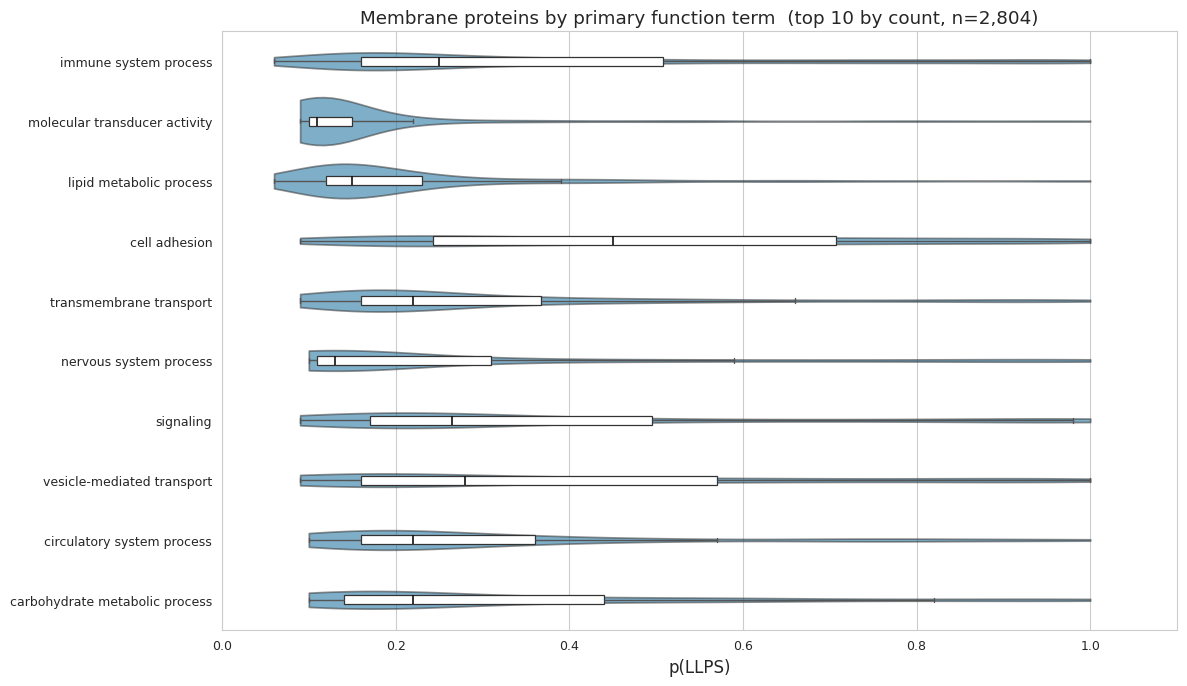

In [7]:
# Fig 6 — Membrane subset: pLLPS by primary function term (top 10 by count)
mem = df[df["Is_Membrane"] == True].copy()
func_long = mem[["p(LLPS)", "Function_Top"]].dropna(subset=["Function_Top"]).query("Function_Top != 'Other'")
func_counts = func_long["Function_Top"].value_counts()
top_funcs = func_counts.nlargest(10).index
func_long = func_long[func_long["Function_Top"].isin(top_funcs)].copy()
order_func = func_counts.loc[top_funcs].sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(12, max(7, 0.35 * len(order_func) + 1.5)))
sns.violinplot(data=func_long, y="Function_Top", x="p(LLPS)", order=order_func,
               inner=None, cut=0, color=C["Membrane"], alpha=0.55, ax=ax)
sns.boxplot(data=func_long, y="Function_Top", x="p(LLPS)", order=order_func,
            width=0.15, showfliers=False, ax=ax,
            boxprops={"facecolor": "white", "edgecolor": "#333333", "linewidth": 0.9},
            whiskerprops={"color": "#555555"}, capprops={"color": "#555555"},
            medianprops={"color": "#111111", "linewidth": 1.2})
ax.set(xlim=(0, 1.1), xlabel="p(LLPS)", ylabel="")
ax.tick_params(axis="y", labelsize=9)
ax.set_title(f"Membrane proteins by primary function term  (top 10 by count, n={len(func_long):,})")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_membrane_by_function.png", dpi=300, bbox_inches="tight")
plt.show()


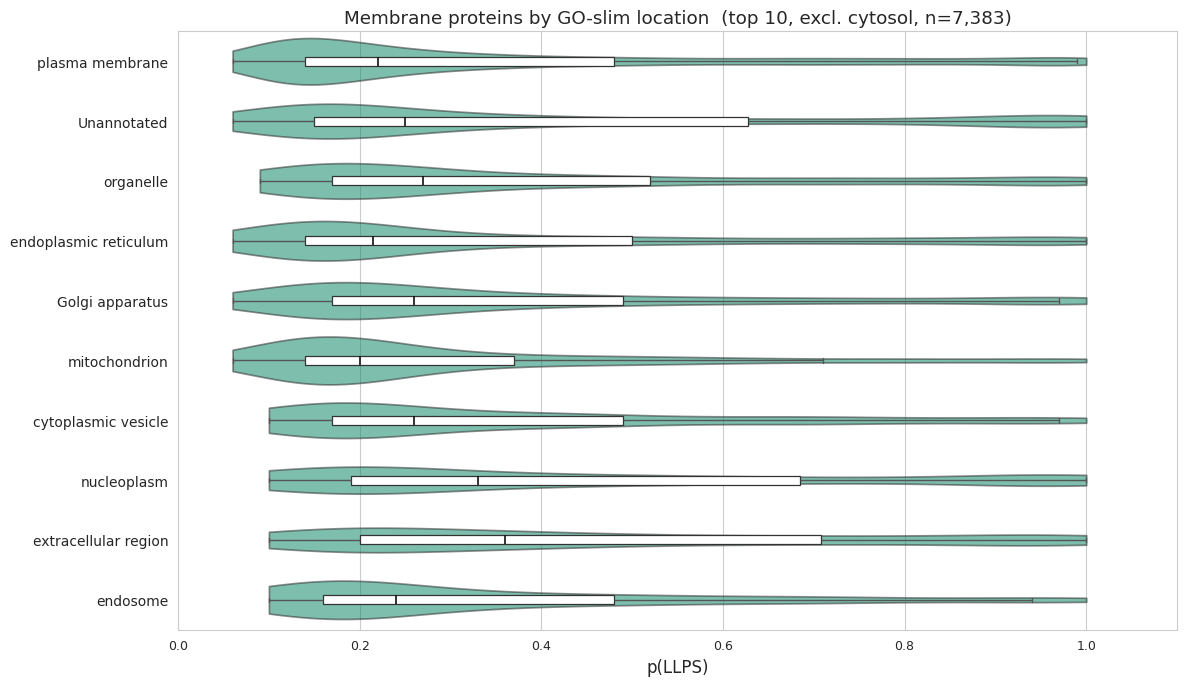

In [8]:
# Fig 7 — Membrane subset: pLLPS by exploded GO-slim location (top 10, excl. cytosol)
loc_long = (
    mem[["p(LLPS)", "Location_Slim_Plot"]]
    .explode("Location_Slim_Plot")
    .dropna(subset=["Location_Slim_Plot"])
    .query("Location_Slim_Plot != 'Other' and Location_Slim_Plot != ''")
    .rename(columns={"Location_Slim_Plot": "Location"})
)
loc_long = loc_long[loc_long["Location"] != "cytosol"]
loc_counts = loc_long["Location"].value_counts()
top_locs = loc_counts.nlargest(10).index
loc_long = loc_long[loc_long["Location"].isin(top_locs)].copy()
order_locs = loc_counts.loc[top_locs].sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(12, max(7, 0.42 * len(order_locs) + 1.5)))
sns.violinplot(data=loc_long, y="Location", x="p(LLPS)", order=order_locs,
               inner=None, cut=0, color=C["Cytosolic"], alpha=0.55, ax=ax)
sns.boxplot(data=loc_long, y="Location", x="p(LLPS)", order=order_locs,
            width=0.15, showfliers=False, ax=ax,
            boxprops={"facecolor": "white", "edgecolor": "#333333", "linewidth": 0.9},
            whiskerprops={"color": "#555555"}, capprops={"color": "#555555"},
            medianprops={"color": "#111111", "linewidth": 1.2})
ax.set(xlim=(0, 1.1), xlabel="p(LLPS)", ylabel="")
ax.tick_params(axis="y", labelsize=10)
ax.set_title(f"Membrane proteins by GO-slim location  (top 10, excl. cytosol, n={len(loc_long):,})")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig7_membrane_by_location.png", dpi=300, bbox_inches="tight")
plt.show()


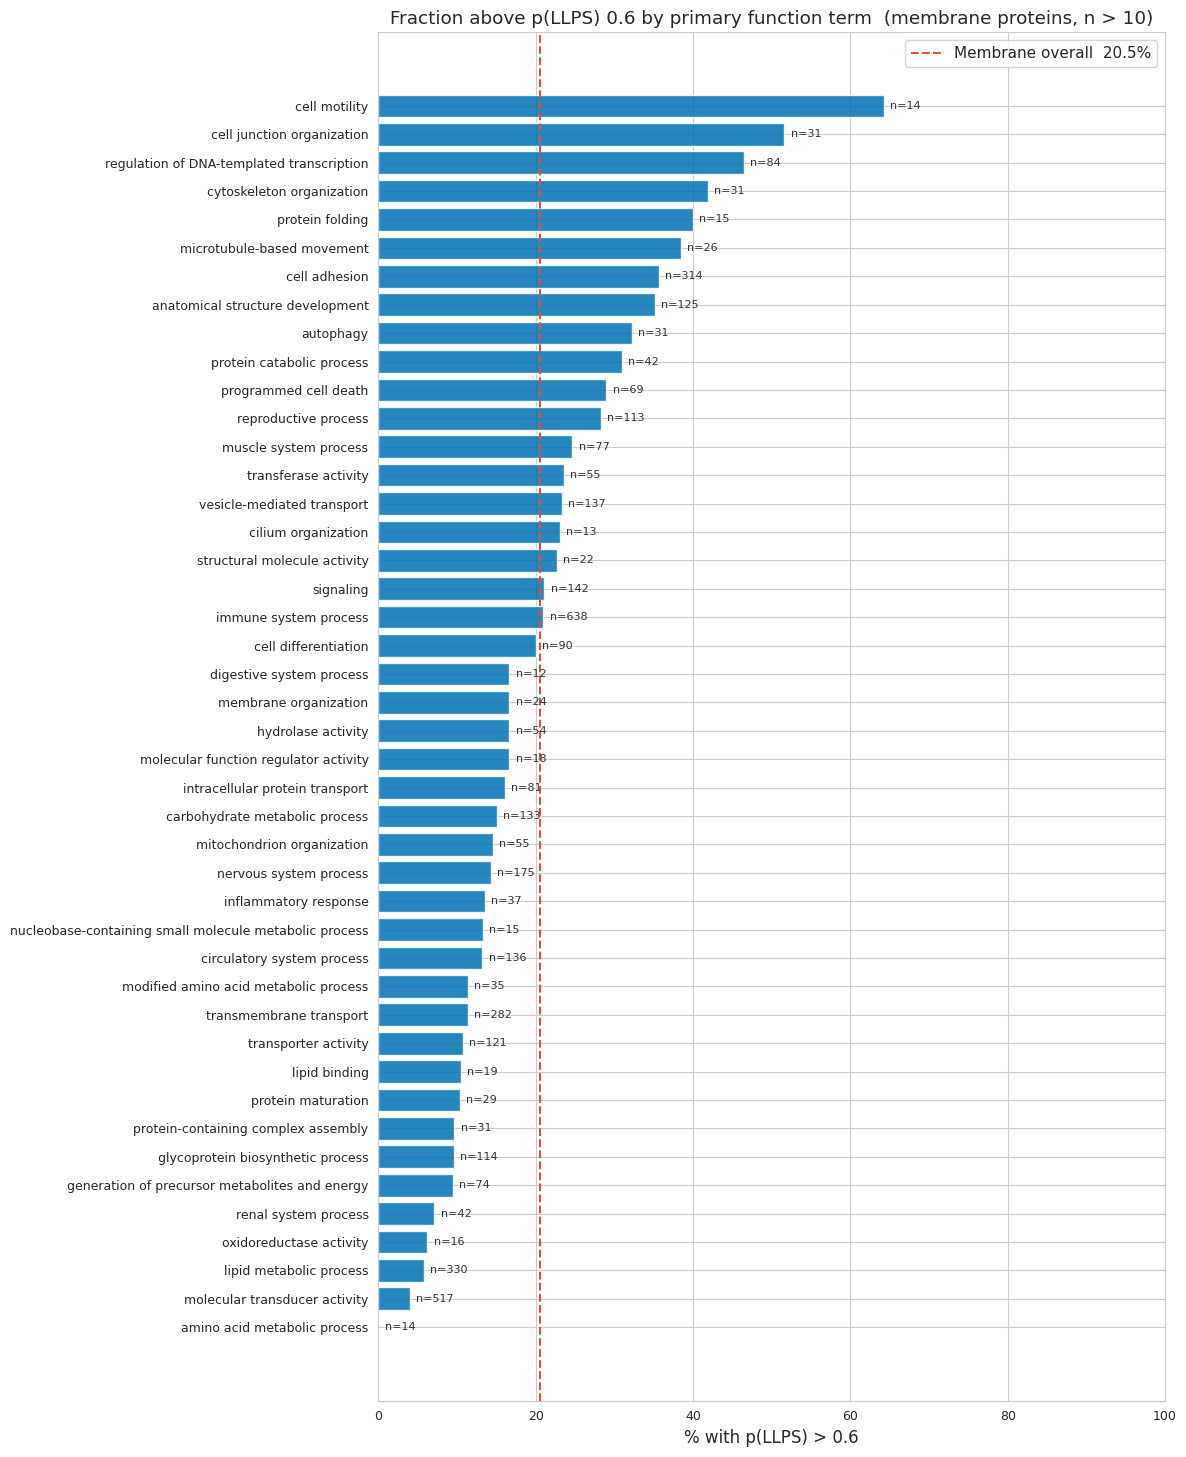

In [9]:
# Fig 8 — % above cutoff by primary function term (membrane subset, n > 10)
overall_pct = 100 * (mem["p(LLPS)"] > CUTOFF).sum() / len(mem)

func_stats = (
    mem[["Function_Top", "p(LLPS)"]].dropna(subset=["Function_Top"])
    .query("Function_Top != 'Other'")
    .groupby("Function_Top")["p(LLPS)"]
    .agg(n="count", n_above=lambda s: (s > CUTOFF).sum())
    .reset_index()
)
func_stats["pct"] = 100 * func_stats["n_above"] / func_stats["n"]
func_stats_filt = func_stats[func_stats["n"] > 10].sort_values("pct", ascending=True)

fig, ax = plt.subplots(figsize=(12, max(7, 0.3 * len(func_stats_filt) + 1.5)))
ax.barh(func_stats_filt["Function_Top"], func_stats_filt["pct"], color=C["Membrane"], alpha=0.85, edgecolor="white")
ax.axvline(overall_pct, color="#e74c3c", linestyle="--", linewidth=1.5,
           label=f"Membrane overall  {overall_pct:.1f}%")
for y, (_, row) in enumerate(func_stats_filt.iterrows()):
    ax.text(row["pct"] + 0.8, y, f"n={int(row['n'])}", va="center", fontsize=8, color="#333333")
ax.set(xlim=(0, max(100, func_stats_filt["pct"].max() * 1.12)), xlabel=f"% with p(LLPS) > {CUTOFF}", ylabel="",
       title=f"Fraction above p(LLPS) {CUTOFF} by primary function term  (membrane proteins, n > 10)")
ax.tick_params(axis="y", labelsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig8_pct_above_cutoff_function.png", dpi=300, bbox_inches="tight")
plt.show()


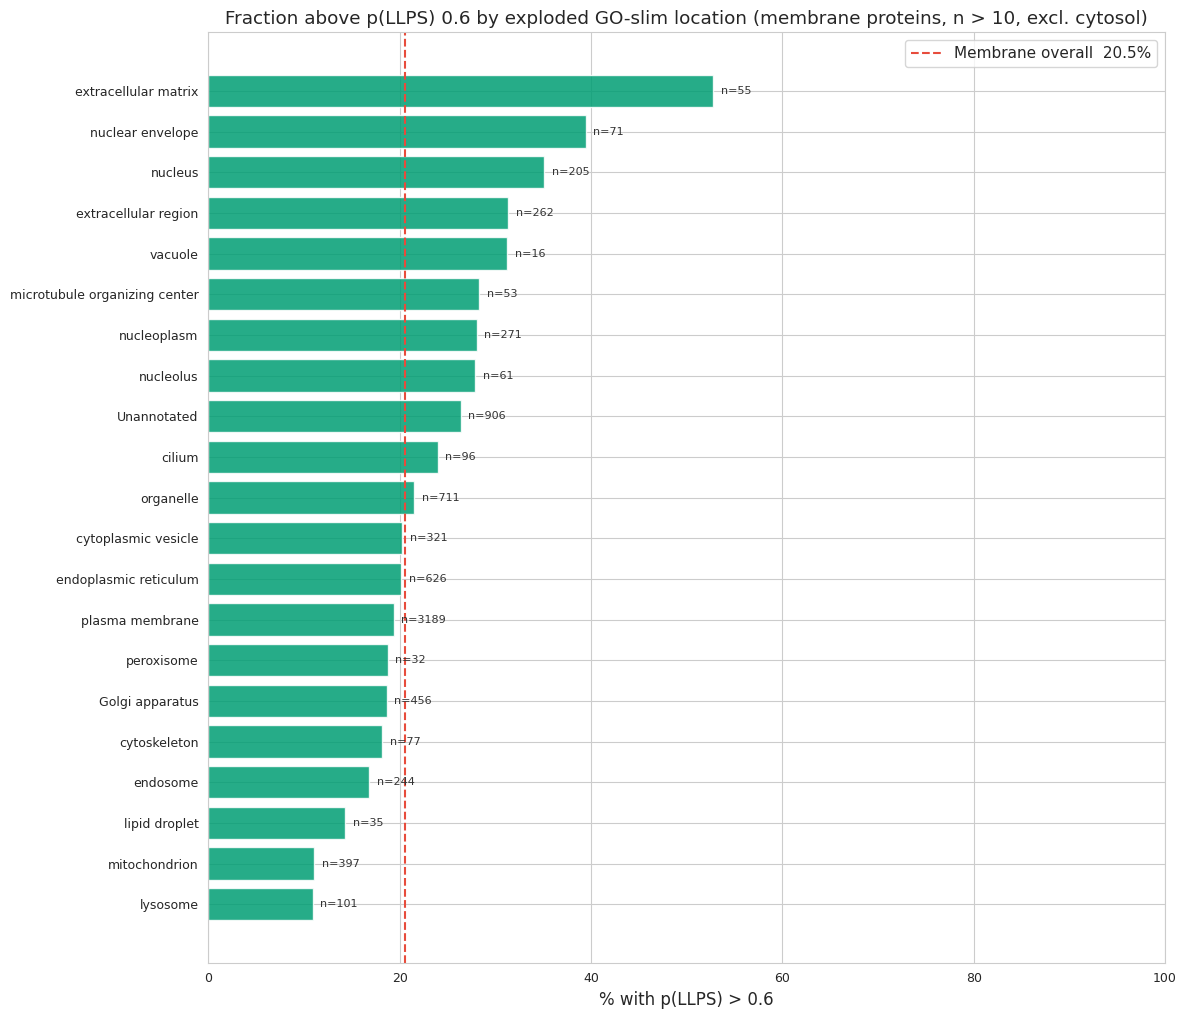

In [10]:
# Fig 9 — % above cutoff by exploded GO-slim location (membrane subset, n > 10, excl. cytosol)
mem = df[df["Is_Membrane"] == True].copy()
loc_stats = (
    mem[["Location_Slim_Plot", "p(LLPS)"]]
    .explode("Location_Slim_Plot")
    .dropna(subset=["Location_Slim_Plot"])
    .query("Location_Slim_Plot != 'Other' and Location_Slim_Plot != ''")
    .query("Location_Slim_Plot != 'cytosol'")
    .groupby("Location_Slim_Plot")["p(LLPS)"]
    .agg(n="count", n_above=lambda s: (s > CUTOFF).sum())
    .reset_index()
)
loc_stats["pct"] = 100 * loc_stats["n_above"] / loc_stats["n"]
loc_stats_filt = loc_stats[loc_stats["n"] > 10].sort_values("pct", ascending=True)

fig, ax = plt.subplots(figsize=(12, max(7, 0.42 * len(loc_stats_filt) + 1.5)))
ax.barh(loc_stats_filt["Location_Slim_Plot"], loc_stats_filt["pct"], color=C["Cytosolic"], alpha=0.85, edgecolor="white")
ax.axvline(overall_pct, color="#e74c3c", linestyle="--", linewidth=1.5,
           label=f"Membrane overall  {overall_pct:.1f}%")
for y, (_, row) in enumerate(loc_stats_filt.iterrows()):
    ax.text(row["pct"] + 0.8, y, f"n={int(row['n'])}", va="center", fontsize=8, color="#333333")
ax.set(xlim=(0, max(100, loc_stats_filt["pct"].max() * 1.12)), xlabel=f"% with p(LLPS) > {CUTOFF}", ylabel="",
       title=f"Fraction above p(LLPS) {CUTOFF} by exploded GO-slim location (membrane proteins, n > 10, excl. cytosol)")
ax.tick_params(axis="y", labelsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig9_pct_above_cutoff_location.png", dpi=300, bbox_inches="tight")
plt.show()


In [11]:
print("Figures written to", FIG_DIR.resolve())
for f in sorted(FIG_DIR.glob("*.png")):
    print(" ", f.name)

Figures written to /home/jake/mem_prot_llps/mem_prot_llps/output/figures
  fig1_pllps_distribution.png
  fig2_membrane_vs_nonmembrane.png
  fig3_by_function.png
  fig3_by_function_observations.png
  fig3_group_size_histograms.png
  fig4_by_location.png
  fig5_kde_distributions.png
  fig5a_kde_all.png
  fig5b_kde_membrane.png
  fig5c_kde_tmd.png
  fig6_membrane_by_function.png
  fig6_membrane_by_function_box.png
  fig6_membrane_by_function_violin.png
  fig6a_membrane_by_function_violin.png
  fig6b_membrane_by_function_box.png
  fig7_membrane_by_location.png
  fig7_membrane_by_location_box.png
  fig7_membrane_by_location_violin.png
  fig7a_membrane_by_location_violin.png
  fig7b_membrane_by_location_box.png
  fig8_pct_above_cutoff_function.png
  fig9_pct_above_cutoff_location.png
